# **Task 3 (Phase 2): Energy Consumption Time Series Forecasting**

## Problem Statement
Forecast short-term household energy consumption using historical time-based
patterns. We compare ARIMA, Prophet, and XGBoost models to find the best
forecasting approach.

## Dataset
- Source: Kaggle — Household Power Consumption Dataset (UCI)
- Original Rows: 2,075,259 (minute-by-minute)
- After Resampling: 1,433 daily records
- Target: Global Active Power (kW)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

In [25]:
df = pd.read_csv('/content/household_power_consumption.txt', sep = ';',
                 low_memory=False, na_values=['?'])

print("Shape:", df.shape)
print("\nCols:", df.columns.tolist())
print("\nFirst 5 rows")
df.head()

Shape: (2075259, 9)

Cols: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

First 5 rows


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


# **Parse & Resample Data**

In [27]:
# Combine Date and Time into single datetime column

if 'Date' in df.columns:
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H:%M:%S')
  # Set Datetime as index
  df.set_index('Datetime', inplace=True)
  df.drop(columns=['Date', 'Time'], inplace=True)

# Convert Global_active_power to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Resample to DAILY average — reduces 2M rows to ~1400 days
df_daily = df['Global_active_power'].resample('D').mean()

# Drop missing values
df_daily.dropna(inplace=True)

print("Shape after resampling:", df_daily.shape)
print("\nFirst 5 rows:")
print(df_daily.head())


Shape after resampling: (1433,)

First 5 rows:
Datetime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Name: Global_active_power, dtype: float64


# **Visualize the Time Series**

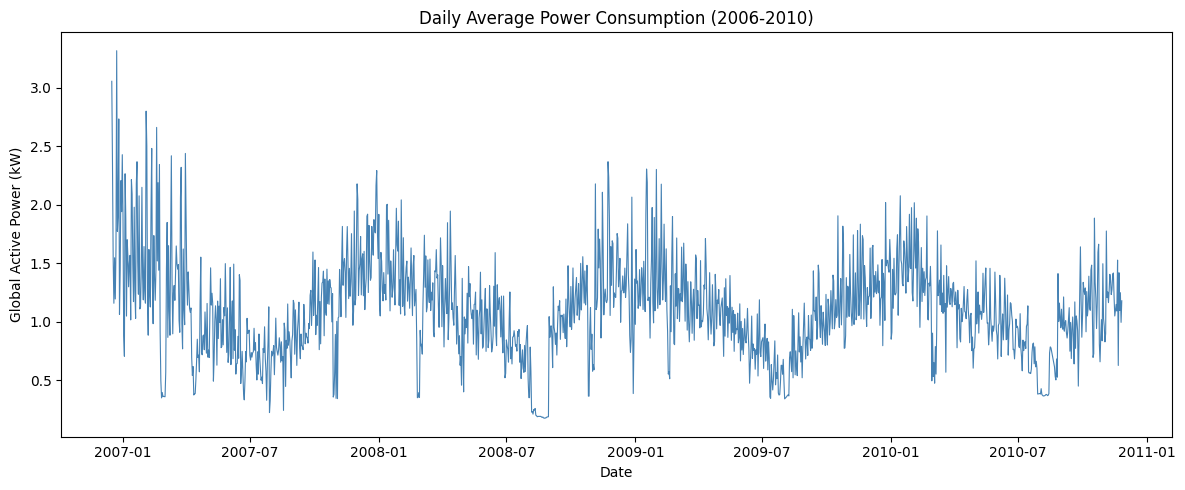

In [28]:
# Plot daily average power consumption
plt.figure(figsize=(12, 5))
plt.plot(df_daily, color='steelblue', linewidth=0.8)
plt.title('Daily Average Power Consumption (2006-2010)')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.show()

# **Feature Engineering**

In [29]:
# convert to dataframe
df_features = df_daily.reset_index()
df_features.columns = ['Datetime', 'Power']


df_features['Month'] = df_features['Datetime'].dt.month
df_features['Day'] = df_features['Datetime'].dt.day
df_features['DayofWeek'] = df_features['Datetime'].dt.dayofweek
df_features['Isweekend'] = df_features['DayofWeek'].apply(lambda x:1 if x>=5 else 0)
df_features['Year'] = df_features['Datetime'].dt.year

# Power from pervious days
df_features['Lag_1'] = df_features['Power'].shift(1)
df_features['Lag_7'] = df_features['Power'].shift(7)
df_features['Lag_30'] = df_features['Power'].shift(30)

# Rolling Features (Summerize the history)
df_features['Roll_7'] = df_features['Power'].rolling(7).mean()
df_features['Roll_30'] = df_features['Power'].rolling(30).mean()

# Drop rows with NaN created by shifting
df_features.dropna(inplace=True)

print("Final features:")
df_features.head()


Final features:


,Datetime,Power,Month,Day,DayofWeek,Isweekend,Year,Lag_1,Lag_7,Lag_30,Roll_7,Roll_30
30,2007-01-15,1.492137,1,15,0,0,2007,2.090213,1.556500,3.053475,1.595808,1.710614
31,2007-01-16,1.171114,1,16,1,0,2007,1.492137,1.297954,2.354486,1.577688,1.671169
32,2007-01-17,1.977561,1,17,2,0,2007,1.171114,1.496389,1.530435,1.646427,1.686073
33,2007-01-18,1.264904,1,18,3,0,2007,1.977561,1.566107,1.157079,1.603398,1.689667
34,2007-01-19,1.028083,1,19,4,0,2007,1.264904,1.014789,1.545658,1.605297,1.672415


# **Train/Test Split for Time Series**

In [30]:
train = df_features[:-90]
test = df_features[-90:]

print("Train Size:", len(train))
print("Test Size:", len(test))


features = ['Month',
    'Day',
    'DayofWeek',
    'Isweekend',
    'Year',
    'Lag_1',
    'Lag_7',
    'Lag_30',
    'Roll_7',
    'Roll_30']

X_train = train[features]
X_test = test[features]
y_train = train['Power']
y_test = test['Power']

print("Train size:", len(train))
print("Test size:", len(test))
print("\nX_train sample:")
print(X_train.head())



Train Size: 1313
Test Size: 90
Train size: 1313
Test size: 90

X_train sample:
    Month  Day  DayofWeek  Isweekend  Year     Lag_1     Lag_7    Lag_30  \
30      1   15          0          0  2007  2.090213  1.556500  3.053475   
31      1   16          1          0  2007  1.492137  1.297954  2.354486   
32      1   17          2          0  2007  1.171114  1.496389  1.530435   
33      1   18          3          0  2007  1.977561  1.566107  1.157079   
34      1   19          4          0  2007  1.264904  1.014789  1.545658   

      Roll_7   Roll_30  
30  1.595808  1.710614  
31  1.577688  1.671169  
32  1.646427  1.686073  
33  1.603398  1.689667  
34  1.605297  1.672415  


# **XGBoost**

In [31]:
from xgboost import XGBRegressor


xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = xgb_model.score(X_test, y_test)

print("XGBoost Results (with Lag Features):")
print(f"MAE:  {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R2:   {xgb_r2:.4f}")




XGBoost Results (with Lag Features):
MAE:  0.1854
RMSE: 0.2524
R2:   0.0784


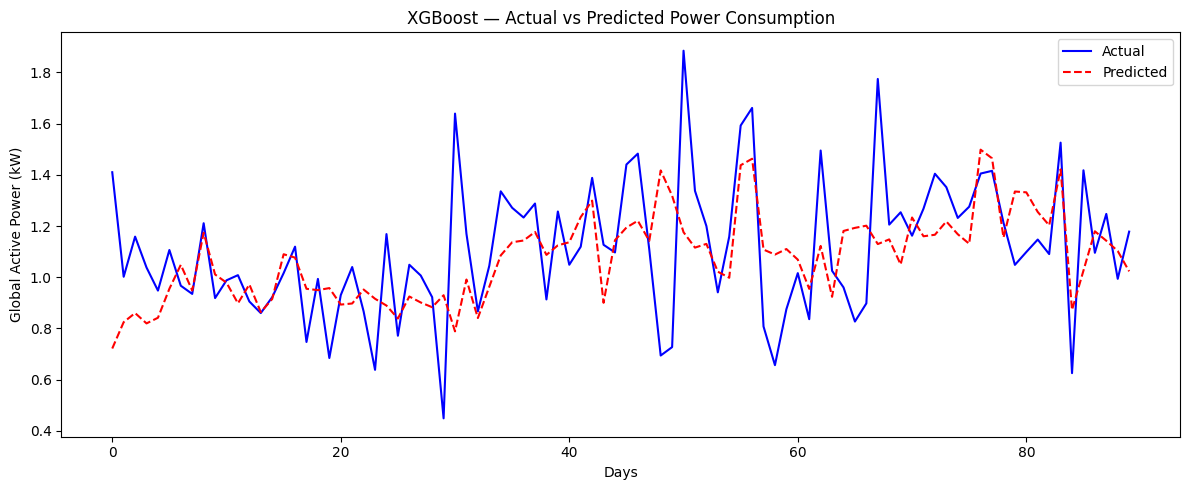

In [32]:
# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(xgb_pred, label='Predicted', color='red', linestyle='--')
plt.title('XGBoost — Actual vs Predicted Power Consumption')
plt.xlabel('Days')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

# **Prophet**

In [33]:
from prophet import Prophet
# Prepare data in Prophet format
df_prophet = df_daily.reset_index()
df_prophet.columns = ['ds', 'y']

df_prophet.head()

,ds,y
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


In [34]:
train_prophet = df_prophet[:-90]
test_prophet = df_prophet[-90:]

prophet_model = Prophet(daily_seasonality=False,
                        weekly_seasonality=True,
                        yearly_seasonality=True)
prophet_model.fit(train_prophet)

# Predict on test period
future = test_prophet[['ds']]
prophet_pred = prophet_model.predict(future)

# Evaluate
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred['yhat']))
prophet_r2 = r2_score(test_prophet['y'], prophet_pred['yhat'])

print("Prophet Results")
print(f"MAE:  {prophet_mae:.4f}")
print(f"RMSE: {prophet_rmse:.4f}")
print(f"R2:   {prophet_r2:.4f}")

Prophet Results
MAE:  0.2138
RMSE: 0.2919
R2:   -0.2321


# **ARIMA (AutoRegressive Integrated Moving Avg)**

In [35]:
from statsmodels.tsa.arima.model import ARIMA

train_arima = train_prophet['y'].values
test_arima = test_prophet['y'].values

# Train ARIMA model
arima_model = ARIMA(train_arima, order=(5, 1, 0))
arima_result = arima_model.fit()

# prediction
arima_pred = arima_result.forecast(steps=90)

# Evaluate
arima_mae = mean_absolute_error(test_arima, arima_pred)
arima_rmae = np.sqrt(mean_squared_error(test_arima, arima_pred))
arima_r2 = r2_score(test_arima, arima_pred)

print("ARIMA Results")
print(f"MAE:  {arima_mae:.4f}")
print(f"RMSE: {arima_rmae:.4f}")
print(f"R2:   {arima_r2:.4f}")

ARIMA Results
MAE:  0.5320
RMSE: 0.5909
R2:   -4.0506


# **Compare All Models Visually**

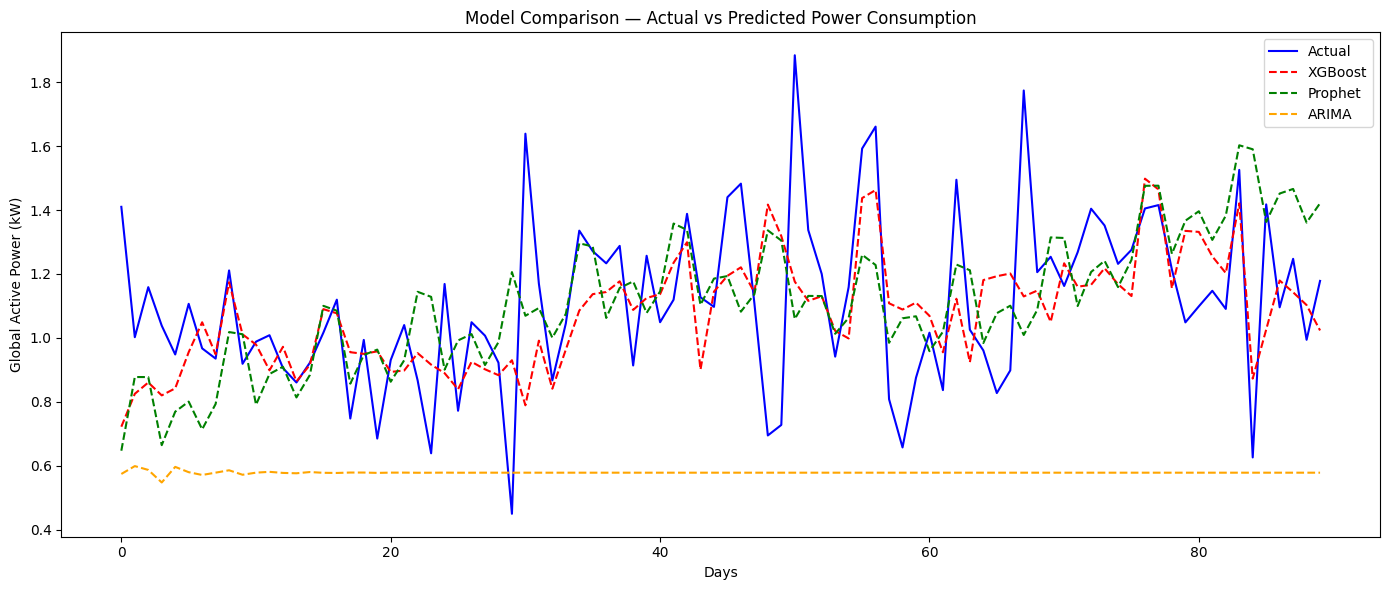

In [36]:
# Plot all 3 models vs actual
plt.figure(figsize=(14, 6))
plt.plot(test_prophet['y'].values, label='Actual', color='blue', linewidth=1.5)
plt.plot(xgb_pred, label='XGBoost', color='red', linestyle='--')
plt.plot(prophet_pred['yhat'].values, label='Prophet', color='green', linestyle='--')
plt.plot(arima_pred, label='ARIMA', color='orange', linestyle='--')
plt.title('Model Comparison — Actual vs Predicted Power Consumption')
plt.xlabel('Days')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

# **Conclusion**

- Dataset resampled from 2M minute records to 1,433 daily records
- Feature engineering added lag features (1, 7, 30 days) and rolling averages
- Three models compared on last 90 days as test set:

| Model   | MAE    | RMSE   | R2     |
|---------|--------|--------|--------|
| XGBoost | 0.1854 | 0.2524 | 0.07   |
| Prophet | 0.2138 | 0.2919 | -0.23  |
| ARIMA   | 0.5320 | 0.5909 | -4.05  |

- XGBoost performed best — lag features captured recent power patterns
- Prophet performed reasonably — handled weekly and yearly seasonality
- ARIMA failed — too simple for complex long-term energy data
- Key insight: Lag features (yesterday, last week, last month) are the
  strongest predictors of energy consumption